In [222]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline

import utils
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
from scipy.signal import detrend
from scipy.stats import pearsonr
from scipy.interpolate import griddata
import glob
import os
from itertools import combinations
from glob import glob

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


A script to measure the correlation and alignment coefficients of paleoseismic and slip rate data

## Alignment coefficient

In [223]:
# dictionary for colors for plotting later 
colors = {
    "ECSZ": "thistle",
    "ECSZLABasin":"coral",
    "Marlborough":"goldenrod",
    "Greece": "thistle",
    "California": "tab:olive",
    "Iceland": "goldenrod",
    "NorthernAppenines":"teal",
    "SouthernAppenines":"teal",
    "Taranaki":"darkseagreen",
    "Taupo":"burlywood"
}


In [224]:
# read all EQ chronologies excel files in directory geo_data_digitized/Paleoseismic data 
import glob

dir_paleoseismo = 'data/geo_data_digitized/Paleoseismic data/chrono/'
eq_chronologies = glob.glob(os.path.join(dir_paleoseismo, '*.xlsx'))
dir_dl_paleo = 'data/geo_data_digitized/Paleoseismic data/DL/'
dl_files_paleo = glob.glob(os.path.join(dir_dl_paleo, '*.xlsx'))

results_alignment = [] # for saving calculations + exporting data later 

dir_moment_release = 'data/geo_data_digitized/Moment release/chrono/'
moment_chronologies = glob.glob(os.path.join(dir_moment_release, '*.csv'))
dir_dl_moment = 'data/geo_data_digitized/Moment release/DL/'
dl_moment_files = glob.glob(os.path.join(dir_dl_moment, '*.xlsx'))

# moment chrono pairs - list of tuples (fault1, fault2)
moment_chrono_pairs = [('ECSZ', 'LABasin')]
results_correlation = []

# slip rate groups
slip_rate_groups = {
    "Marlborough": ["Hope", "Awatere", "Clarence", "Wairau"],
    "Greece": ["Pisia", "Skinos"],
    "California": ["SanAndreas", "SanJacinto"],
    "NorthernAppenines":["Velino", "CampoFelice"],
    "SouthernAppenines":["TrasaccoCentral","Parasano","SanSebastiano"],
    "Taranaki":["Ihaia","Kina","Oaonui","Pihama","Kiri","Rahotu"],
    "Taupo":["Paeroa","Ngakuru","Whirinaki","Maleme"]
}

slip_rate_dir = "data/geo_data_digitized/Incremental slip rates/chrono/"
slip_rate_files = glob.glob(os.path.join(slip_rate_dir, '*.csv'))

# group slip rate files by slip_rate_groups
grouped_slip_rate_files = {}

for group_name, fault_names in slip_rate_groups.items():
    grouped_slip_rate_files[group_name] = {}
    
    for fault_name in fault_names:
        grouped_slip_rate_files[group_name][fault_name] = {
            "upper": None,
            "lower": None,
            "single": None,
        }
        
        for file in slip_rate_files:
            basename = os.path.basename(file)
            
            if basename.startswith(f"{fault_name}_upper"):
                grouped_slip_rate_files[group_name][fault_name]["upper"] = file
            
            elif basename.startswith(f"{fault_name}_lower"):
                grouped_slip_rate_files[group_name][fault_name]["lower"] = file
            
            elif basename == f"{fault_name}.csv":
                grouped_slip_rate_files[group_name][fault_name]["single"] = file


In [225]:
results_alignment = []

for eq_chronology in eq_chronologies:
    eq_chronology_data = pd.read_excel(eq_chronology)
    chrono_name = os.path.splitext(os.path.basename(eq_chronology))[0].split('_', 1)[1]

    for dl_file in dl_files_paleo:
        dl_name = os.path.splitext(os.path.basename(dl_file))[0]

        if chrono_name in dl_name:
            dl_fault = pd.read_excel(dl_file)

            dl_fault[["Fault 1", "Fault 2"]] = np.sort(
                dl_fault[["Fault 1", "Fault 2"]], axis=1
            )
            dl_fault["D_true"] = np.sqrt(
                (dl_fault["D_x1"] - dl_fault["D_x2"])**2 +
                (dl_fault["D_y1"] - dl_fault["D_y2"])**2
            )

            for (fault1, fault2), group in dl_fault.groupby(["Fault 1", "Fault 2"]):
                D_vals = group["D_true"].to_numpy()
                L_vals = group["L"].to_numpy()
                D_L_matrix = D_vals[:, None] / L_vals[None, :]

                fault1_events_tmin = eq_chronology_data[
                    eq_chronology_data['Fault'] == fault1]['tmin'].to_numpy()
                fault1_events_tmax = eq_chronology_data[
                    eq_chronology_data['Fault'] == fault1]['tmax'].to_numpy()
                fault2_events_tmin = eq_chronology_data[
                    eq_chronology_data['Fault'] == fault2]['tmin'].to_numpy()
                fault2_events_tmax = eq_chronology_data[
                    eq_chronology_data['Fault'] == fault2]['tmax'].to_numpy()

                if len(fault1_events_tmin) < 2 or len(fault1_events_tmax) < 2:
                    print("reference fault has <2 events")
                    continue
                if len(fault2_events_tmin) == 0 or len(fault2_events_tmax) == 0:
                    print("comparison fault has 0 events")
                    continue

                mc = utils.alignment_MC(
                    fault1_events_tmin, fault1_events_tmax,
                    fault2_events_tmin, fault2_events_tmax,
                    n_mc=1000
                )
                
                ac12 = mc["ac_12"]
                ac21 = mc["ac_21"]

                for reference_fault, ac in [(fault1, ac12), (fault2, ac21)]:
                    results_alignment.append({
                        "Fault 1":         fault1,
                        "Fault 2":         fault2,
                        "N_realizations":  len(group),
                        "D_min":           D_vals.min(),
                        "D_mean":          D_vals.mean(),
                        "D_max":           D_vals.max(),
                        "L_min":           L_vals.min(),
                        "L_mean":          L_vals.mean(),
                        "L_max":           L_vals.max(),
                        "D/L_min":         np.min(D_L_matrix),
                        "D/L_mean":        np.mean(D_L_matrix),
                        "D/L_max":         np.max(D_L_matrix),
                        "Fault system":    chrono_name,
                        "color":           colors[chrono_name],
                        "reference_fault": reference_fault,
                        "ac_mean":         ac["midpoint"],
                        "ac_p5":           ac["p5"],
                        "ac_p95":          ac["p95"],
                    })
results_alignment_df = pd.DataFrame(results_alignment)
results_alignment_df.to_csv(
    'code_output_data/paleoseismic_alignment_parameters_DL.csv', index=False
)

reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference fault has <2 events
reference 

## Correlation coefficient

Moment release

In [226]:
results_correlation = []

for fault1, fault2 in moment_chrono_pairs:
    files = utils.get_moment_files_for_pair(fault1, fault2, dir_moment_release, dir_dl_moment)
    moment_f1 = pd.read_csv(files['fault1_file'])
    moment_f2 = pd.read_csv(files['fault2_file'])
    dl = pd.read_excel(files['dl_file'])

    dl_basename = os.path.basename(files['dl_file'])
    system_name = os.path.splitext(dl_basename)[0].split('_', 1)[1]

    dl[["Fault 1", "Fault 2"]] = np.sort(dl[["Fault 1", "Fault 2"]], axis=1)
    dl["D_true"] = np.sqrt(
        (dl["D_x1"] - dl["D_x2"])**2 +
        (dl["D_y1"] - dl["D_y2"])**2
    )

    for (f1, f2), group in dl.groupby(["Fault 1", "Fault 2"]):
        D_vals = group["D_true"].to_numpy()
        L_vals = group["L"].to_numpy()
        D_L_matrix = D_vals[:, None] / L_vals[None, :]

        f1_years = moment_f1['Year'].to_numpy()
        f2_years = moment_f2['Year'].to_numpy()
        f1_rates = moment_f1['Moment'].to_numpy()
        f2_rates = moment_f2['Moment'].to_numpy()

        mc = utils.moment_correlation_MC(
            f1_years, f1_rates,
            f2_years, f2_rates,
            uncertainty_fraction=0.20,
            n_mc=1000
        )

        results_correlation.append({
            "Fault 1":       f1,
            "Fault 2":       f2,
            "N_realizations": len(group),
            "D_min":         D_vals.min(),
            "D_mean":        D_vals.mean(),
            "D_max":         D_vals.max(),
            "L_min":         L_vals.min(),
            "L_mean":        L_vals.mean(),
            "L_max":         L_vals.max(),
            "D/L_min":       np.min(D_L_matrix),
            "D/L_mean":      np.mean(D_L_matrix),
            "D/L_max":       np.max(D_L_matrix),
            "corr_mean":     mc["corr_mean"],
            "corr_std":      mc["corr_std"],
            "corr_p5":       mc["corr_p5"],
            "corr_p95":      mc["corr_p95"],
            "ci_spans_zero": ci_spans_zero,
            "Fault system":  system_name,
            "color":         colors[system_name],
        })

results_correlation_df = pd.DataFrame(results_correlation)
results_correlation_df.to_csv(
    'code_output_data/moment_release_correlation_DL.csv', index=False
)


Slip rates

In [227]:
processed_slip_rates = {}

for group_name, faults in grouped_slip_rate_files.items():
    processed_slip_rates[group_name] = {}
    
    for fault_name, files in faults.items():
        processed_slip_rates[group_name][fault_name] = {}
        
        valid_files = {k: v for k, v in files.items() if v is not None}
        
        if 'upper' in valid_files and 'lower' in valid_files:
            bounds = ['upper', 'lower']
        elif len(valid_files) == 1:
            bounds = ['single']
            single_path = list(valid_files.values())[0]

        temp_results = {}
        
        for bound in bounds:
            path = valid_files[bound] if bound != 'single' else single_path
            data = pd.read_csv(path)
            data.columns = data.columns.str.strip()
            time_col = data.columns[0]
            value_col = data.columns[1]
            times = data[time_col].to_numpy()
            values = data[value_col].to_numpy()
            
            if len(times) > 1:
                sort_idx = np.argsort(times)
                times = times[sort_idx]
                values = values[sort_idx]
            
            if 'slip' in value_col.lower() and 'rate' not in value_col.lower():
                t0 = times - np.mean(times)
                coef = np.polyfit(t0, values, 1)
                trend = np.polyval(coef, t0)
                residuals = values - trend
                slip_rate = residuals - np.mean(residuals)
                data_type = 'Slip (detrended & centered)'
            else:
                slip_rate = values - np.mean(values)
                data_type = 'Slip rate (centered)'
            
            temp_results[bound] = {
                'time': times,
                'slip_rate': slip_rate,
                'data_type': data_type
            }
        
        if 'single' in temp_results:
            processed_slip_rates[group_name][fault_name]['upper'] = temp_results['single']
            processed_slip_rates[group_name][fault_name]['lower'] = temp_results['single']
        else:
            processed_slip_rates[group_name][fault_name]['upper'] = temp_results['upper']
            processed_slip_rates[group_name][fault_name]['lower'] = temp_results['lower']

In [228]:
dir_dl_slip_rate = 'data/geo_data_digitized/Incremental slip rates/DL/'
results_slip_rate_correlation = []

for group_name, faults in processed_slip_rates.items():
    dl_path = os.path.join(dir_dl_slip_rate, f"DL_{group_name}.xlsx")

    dl = pd.read_excel(dl_path)
    dl[["Fault 1", "Fault 2"]] = np.sort(dl[["Fault 1", "Fault 2"]], axis=1)
    dl["D_true"] = np.sqrt(
        (dl["D_x1"] - dl["D_x2"])**2 +
        (dl["D_y1"] - dl["D_y2"])**2
    )

    fault_names = list(faults.keys())
    for i, fault1 in enumerate(fault_names):
        for fault2 in fault_names[i+1:]:
            f1_sorted, f2_sorted = sorted([fault1, fault2])
            group = dl[
                (dl["Fault 1"] == f1_sorted) & (dl["Fault 2"] == f2_sorted)
            ]

            D_vals = group["D_true"].dropna().to_numpy()
            L_vals = group["L"].dropna().to_numpy()

            if len(D_vals) == 0 or len(L_vals) == 0:
                print(f"WARNING: empty D/L for {fault1}-{fault2} in {group_name}, skipping")
                continue
            D_L_matrix = D_vals[:, None] / L_vals[None, :]

            d1 = faults[fault1]
            d2 = faults[fault2]

            mc = utils.slip_rate_correlation_MC(
                d1["upper"], d1["lower"], d2["upper"], d2["lower"], n_mc=1000
            )

            results_slip_rate_correlation.append({
                "group":         group_name,
                "fault1":        fault1,
                "fault2":        fault2,
                "N_realizations": len(group),
                "D_min":         D_vals.min(),
                "D_mean":        D_vals.mean(),
                "D_max":         D_vals.max(),
                "L_min":         L_vals.min(),
                "L_mean":        L_vals.mean(),
                "L_max":         L_vals.max(),
                "D/L_min":       np.min(D_L_matrix),
                "D/L_mean":      np.mean(D_L_matrix),
                "D/L_max":       np.max(D_L_matrix),
                "corr_mean":     mc["corr_mean"],
                "corr_p5":       mc["corr_p5"],
                "corr_p95":      mc["corr_p95"],
                "color":         colors.get(group_name),
            })

df_slip_rate_correlation = pd.DataFrame(results_slip_rate_correlation)
df_slip_rate_correlation.to_csv("code_output_data/slip_rate_correlation_DL.csv", index=False)

In [229]:
from glob import glob 
grouped_slip_rate_files = {}

for group_name in ["Greece"]:  
    grouped_slip_rate_files[group_name] = {}
    
    files = glob("chrono/*.csv")
    
    for path in files:
        fname = os.path.basename(path)
        name = fname.replace(".csv", "")
        
        if name.endswith("_upper"):
            fault = name.replace("_upper", "")
            bound = "upper"
        elif name.endswith("_lower"):
            fault = name.replace("_lower", "")
            bound = "lower"
        else:
            fault = name
            bound = "single"
        
        grouped_slip_rate_files[group_name].setdefault(fault, {})
        grouped_slip_rate_files[group_name][fault][bound] = path


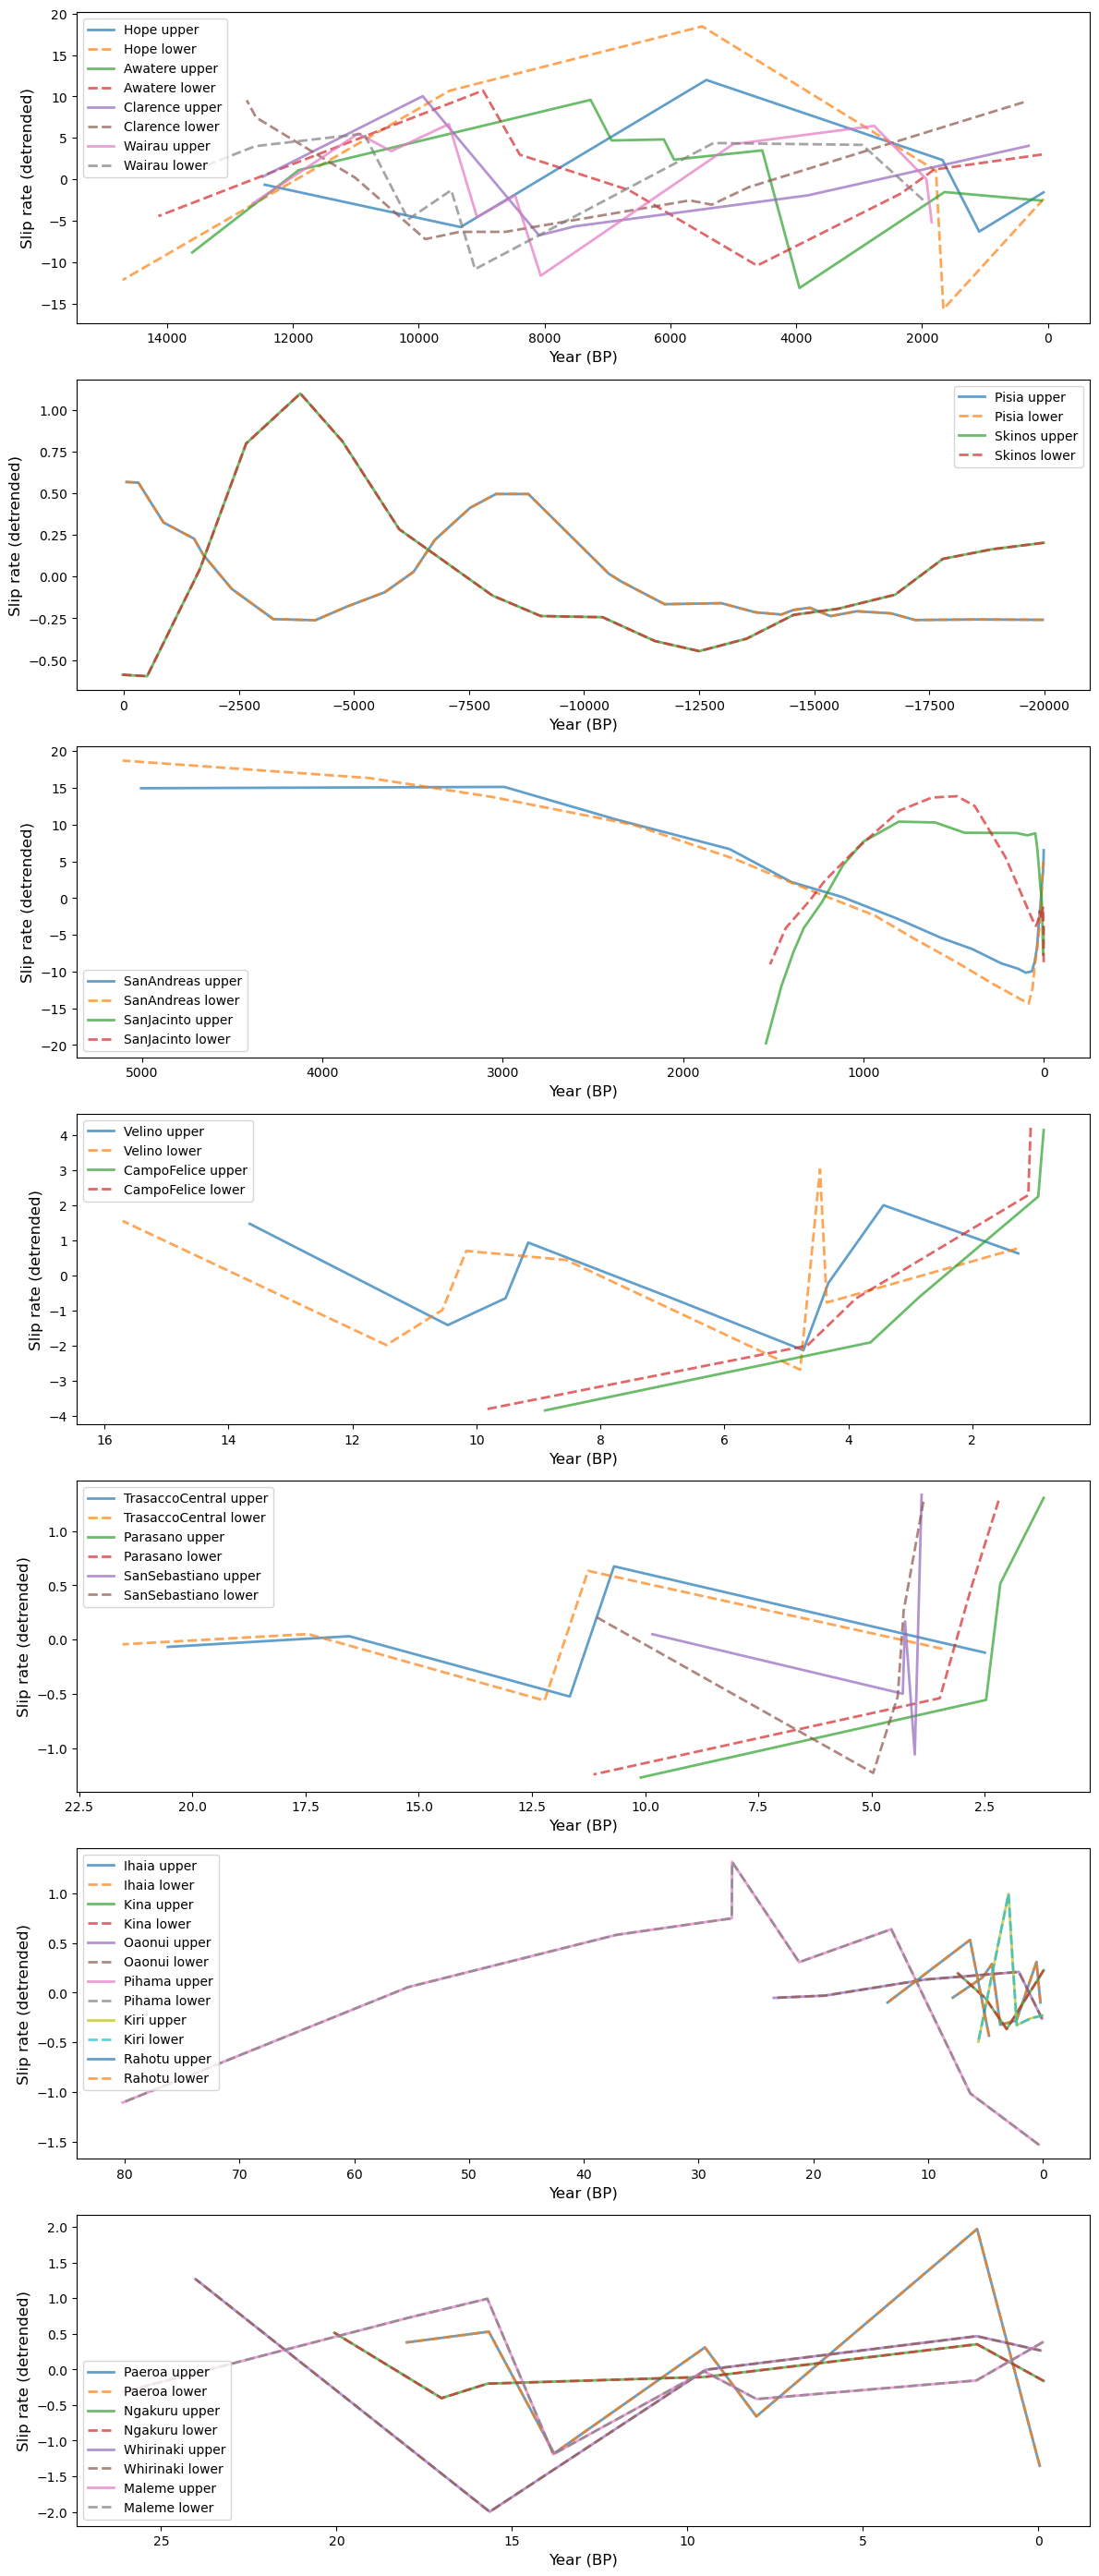

In [230]:
fig, axes = plt.subplots(len(processed_slip_rates), 1, figsize=(12, 4*len(processed_slip_rates)))

if len(processed_slip_rates) == 1:
    axes = [axes]

for idx, (group_name, faults) in enumerate(processed_slip_rates.items()):
    ax = axes[idx]
    
    
    for fault_name, bounds in faults.items():
        upper = bounds['upper']
        ax.plot(upper['time'], upper['slip_rate'], '-', label=f"{fault_name} upper", linewidth=2, alpha=0.7)
        lower = bounds['lower']
        ax.plot(lower['time'], lower['slip_rate'], '--', label=f"{fault_name} lower", linewidth=2, alpha=0.7)
    
    ax.set_xlabel('Year (BP)', fontsize=12)
    ax.set_ylabel('Slip rate (detrended)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.invert_xaxis()

plt.tight_layout()



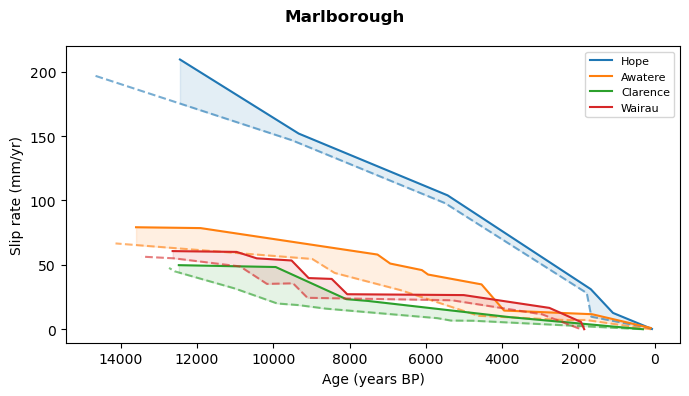

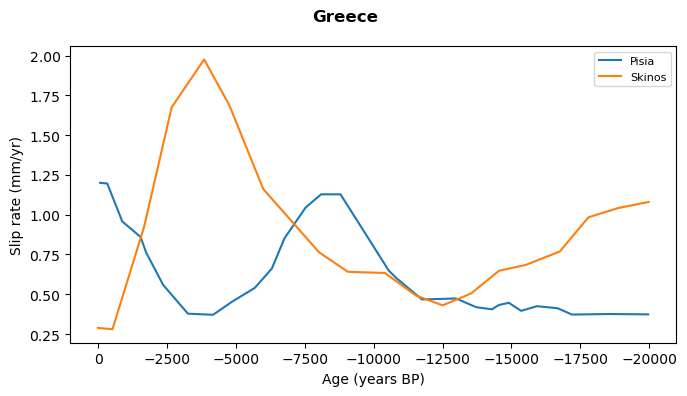

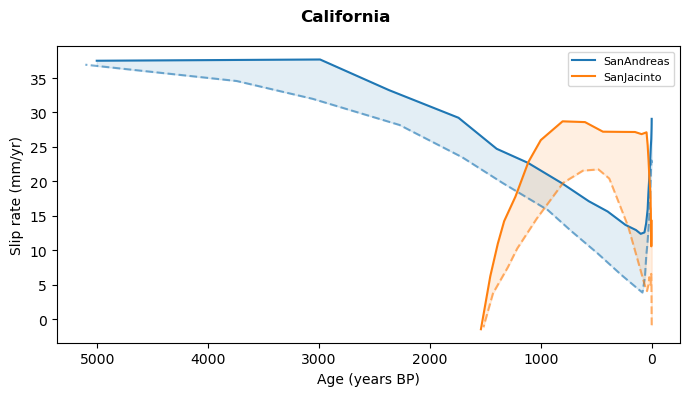

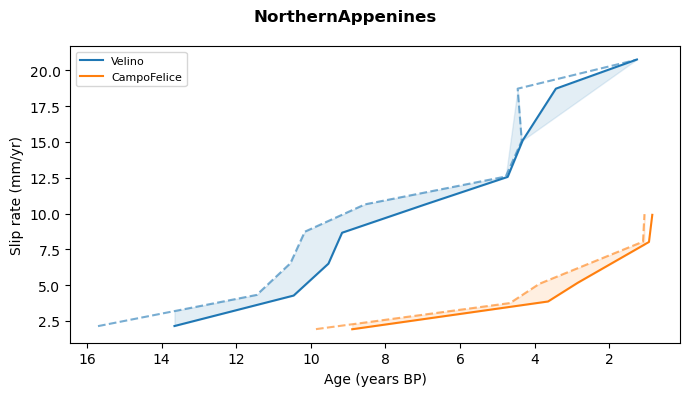

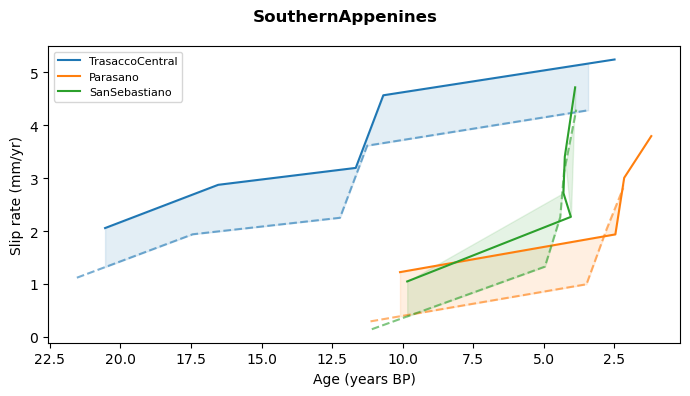

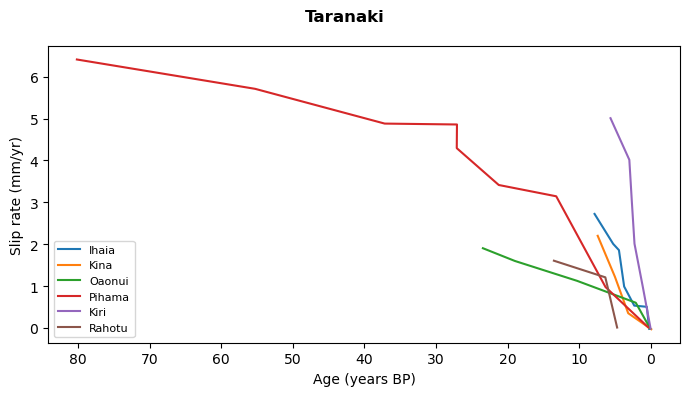

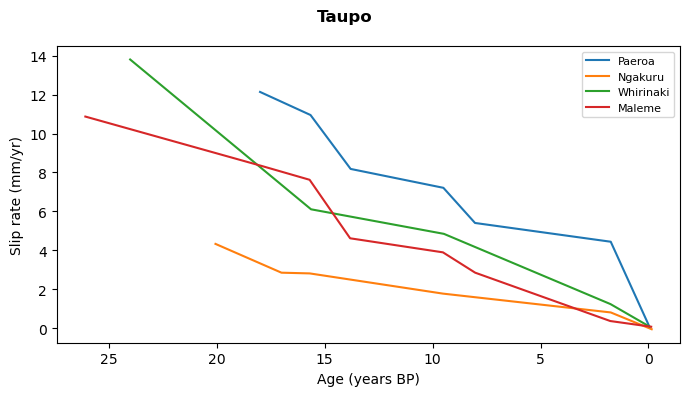

In [231]:
import glob as glob_module

slip_rate_dir = "data/geo_data_digitized/Incremental slip rates/chrono/"
slip_rate_files = glob_module.glob(os.path.join(slip_rate_dir, '*.csv'))

grouped_slip_rate_files = {}

for group_name, fault_names in slip_rate_groups.items():
    grouped_slip_rate_files[group_name] = {}
    
    for fault_name in fault_names:
        grouped_slip_rate_files[group_name][fault_name] = {
            "upper": None,
            "lower": None,
            "single": None,
        }
        
        for file in slip_rate_files:
            basename = os.path.basename(file)
            
            if basename.startswith(f"{fault_name}_upper"):
                grouped_slip_rate_files[group_name][fault_name]["upper"] = file
            elif basename.startswith(f"{fault_name}_lower"):
                grouped_slip_rate_files[group_name][fault_name]["lower"] = file
            elif basename == f"{fault_name}.csv":
                grouped_slip_rate_files[group_name][fault_name]["single"] = file

# plot raw digitized slip rate data pero group

fault_colors = plt.cm.tab10.colors

for group_name, fault_files in grouped_slip_rate_files.items():
    if len(fault_files) == 0:
        print(f"Skipping {group_name}: no fault files found")
        continue

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.suptitle(group_name, fontsize=12, fontweight='bold')

    for i, (fault_name, files) in enumerate(fault_files.items()):
        color = fault_colors[i % len(fault_colors)]
        valid_files = {k: v for k, v in files.items() if v is not None}

        if 'upper' in valid_files and 'lower' in valid_files:
            df_upper = pd.read_csv(valid_files['upper'])
            df_upper.columns = df_upper.columns.str.strip()
            df_lower = pd.read_csv(valid_files['lower'])
            df_lower.columns = df_lower.columns.str.strip()

            x_col = df_upper.columns[0]
            y_col = df_upper.columns[1]

            xu = df_upper[x_col].to_numpy(float)
            yu = df_upper[y_col].to_numpy(float)
            xl = df_lower[x_col].to_numpy(float)
            yl = df_lower[y_col].to_numpy(float)
            x_lo = max(xu.min(), xl.min())
            x_hi = min(xu.max(), xl.max())

            ax.plot(xu, yu, '-',  color=color, lw=1.5, label=fault_name)
            ax.plot(xl, yl, '--', color=color, lw=1.5, alpha=0.6)

            if x_lo < x_hi:
                x_common = np.linspace(x_lo, x_hi, 500)
                y_upper_interp = np.interp(x_common, np.sort(xu), yu[np.argsort(xu)])
                y_lower_interp = np.interp(x_common, np.sort(xl), yl[np.argsort(xl)])
                ax.fill_between(x_common, y_lower_interp, y_upper_interp,
                                alpha=0.12, color=color)

        elif 'single' in valid_files:
            df = pd.read_csv(valid_files['single'])
            df.columns = df.columns.str.strip()
            x_col = df.columns[0]
            y_col = df.columns[1]
            ax.plot(df[x_col], df[y_col], '-', color=color, lw=1.5, label=fault_name)

        else:
            continue

    ax.set_xlabel("Age (years BP)", fontsize=10)
    ax.set_ylabel("Slip rate (mm/yr)", fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.invert_xaxis()

    plt.tight_layout()
    plt.savefig(f"Summary figures/data_digi/QC_slip_rate_{group_name}.png",
                bbox_inches='tight', dpi=150)
    plt.show()

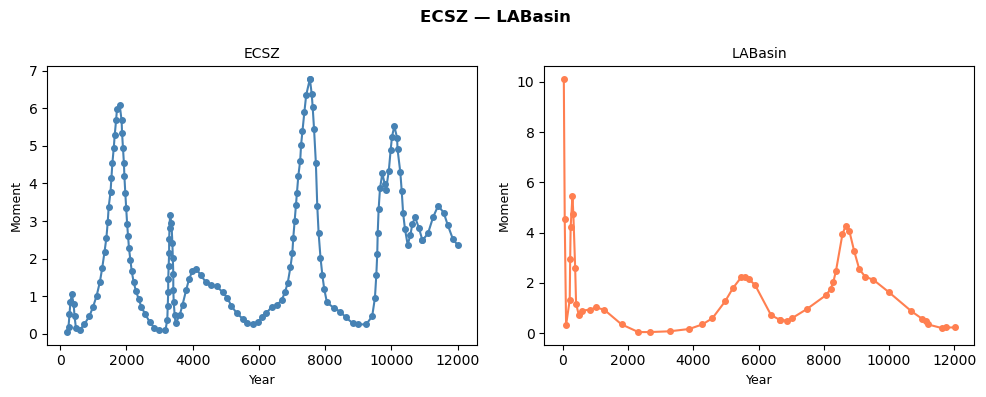

In [232]:
# plot raw digitized moment release data 
for fault1, fault2 in moment_chrono_pairs:
    files = utils.get_moment_files_for_pair(fault1, fault2, dir_moment_release, dir_dl_moment)

    moment_f1 = pd.read_csv(files['fault1_file'])
    moment_f2 = pd.read_csv(files['fault2_file'])

    x_col_f1 = moment_f1.columns[0]
    y_col_f1 = moment_f1.columns[1]
    x_col_f2 = moment_f2.columns[0]
    y_col_f2 = moment_f2.columns[1]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{fault1} — {fault2}", fontsize=12, fontweight='bold')

    axes[0].plot(moment_f1[x_col_f1], moment_f1[y_col_f1],
                 '-o', color='steelblue', lw=1.5, ms=4)
    axes[0].set_title(fault1, fontsize=10)
    axes[0].set_xlabel(x_col_f1, fontsize=9)
    axes[0].set_ylabel(y_col_f1, fontsize=9)

    axes[1].plot(moment_f2[x_col_f2], moment_f2[y_col_f2],
                 '-o', color='coral', lw=1.5, ms=4)
    axes[1].set_title(fault2, fontsize=10)
    axes[1].set_xlabel(x_col_f2, fontsize=9)
    axes[1].set_ylabel(y_col_f2, fontsize=9)

    plt.tight_layout()
    plt.savefig(f"Summary figures/data_digi/QC_moment_release_{fault1}_{fault2}.png",
                bbox_inches='tight', dpi=150)
    plt.show()